In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

print("Setup OK")
print("scikit-learn:", sklearn.__version__)

Setup OK
scikit-learn: 1.9.1


In [8]:
import os

print([f for f in os.listdir() if "house_prices" in f.lower()])

['house_prices.csv']


In [9]:
df = pd.read_csv("house_prices.csv")

print(df.shape)
df.head()

(187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [10]:
print(df.columns.tolist())
print(df.info())

['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 no

In [11]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
}).sort_values("Missing Percent", ascending=False)

missing_table

,Missing Count,Missing Percent
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


In [12]:
df = df.drop(columns=["Plot Area", "Dimensions"])

print(df.shape)

(187531, 19)


In [13]:
df = df.dropna(subset=["Price (in rupees)"])

print(df.shape)
print(df["Price (in rupees)"].isnull().sum())

(169866, 19)
0


In [14]:
for col in ["Carpet Area", "Floor", "Bathroom", "Balcony", "Super Area"]:
    print("\n", col)
    print(df[col].dropna().unique()[:20])


 Carpet Area
<StringArray>
[ '500 sqft',  '473 sqft',  '779 sqft',  '635 sqft',  '550 sqft',  '900 sqft',
  '950 sqft', '1820 sqft',  '675 sqft',  '647 sqft',  '600 sqft',  '430 sqft',
  '665 sqft',  '557 sqft',  '870 sqft',  '288 sqft',  '925 sqft',  '434 sqft',
 '1350 sqft',  '850 sqft']
Length: 20, dtype: str

 Floor
<StringArray>
[   '10 out of 11',     '3 out of 22',    '10 out of 29',    '20 out of 42',
      '2 out of 7',      '4 out of 5', 'Ground out of 7', 'Ground out of 2',
     '3 out of 27',     '6 out of 20',    '16 out of 24',     '8 out of 20',
    '18 out of 27',      '2 out of 3',    '10 out of 16',      '5 out of 7',
    '20 out of 28',      '3 out of 3',      '3 out of 7',    '15 out of 31']
Length: 20, dtype: str

 Bathroom
<StringArray>
['1', '2', '3', '4', '6', '5', '9', '8', '> 10', '7', '10']
Length: 11, dtype: str

 Balcony
<StringArray>
['2', '1', '3', '4', '6', '5', '7', '> 10', '10', '8', '9']
Length: 11, dtype: str

 Super Area
<StringArray>
[ '680 sqft',

In [16]:
area = df["Carpet Area"].str.strip()

sqm_mask = area.str.contains("sqm", na=False)

area = (
    area
    .str.replace(" sqft", "", regex=False)
    .str.replace(" sqm", "", regex=False)
)

df["Carpet Area"] = pd.to_numeric(area, errors="coerce")

df.loc[sqm_mask, "Carpet Area"] *= 10.764

print(df["Carpet Area"].head(10))
print(df["Carpet Area"].dtype)

0     500.0
1     473.0
2     779.0
4     635.0
5       NaN
6     550.0
7       NaN
8       NaN
9     900.0
10    950.0
Name: Carpet Area, dtype: float64
float64


In [17]:
floor = df["Floor"].astype(str).str.strip()

df["floor_num"] = (
    floor
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

# Ground floor = 0
df.loc[floor.str.contains("Ground", case=False, na=False), "floor_num"] = 0

print(df[["Floor", "floor_num"]].head(15))
print(df["floor_num"].dtype)

              Floor  floor_num
0      10 out of 11       10.0
1       3 out of 22        3.0
2      10 out of 29       10.0
4      20 out of 42       20.0
5        2 out of 7        2.0
6        4 out of 5        4.0
7   Ground out of 7        0.0
8   Ground out of 2        0.0
9       3 out of 27        3.0
10      6 out of 20        6.0
11     16 out of 24       16.0
12      8 out of 20        8.0
13     18 out of 27       18.0
14       2 out of 3        2.0
15     10 out of 16       10.0
float64


In [18]:
df["bathroom_num"] = (
    df["Bathroom"]
    .astype(str)
    .str.replace("> 10", "11", regex=False)
    .str.strip()
)

df["bathroom_num"] = pd.to_numeric(
    df["bathroom_num"],
    errors="coerce"
)

print(df[["Bathroom", "bathroom_num"]].head(15))
print(df["bathroom_num"].dtype)

   Bathroom  bathroom_num
0         1           1.0
1         2           2.0
2         2           2.0
4         2           2.0
5         1           1.0
6         1           1.0
7         1           1.0
8         1           1.0
9         3           3.0
10        2           2.0
11        2           2.0
12        2           2.0
13        4           4.0
14        1           1.0
15        2           2.0
float64


In [19]:
df["balcony_num"] = (
    df["Balcony"]
    .astype(str)
    .str.strip()
    .str.extract(r"(\d+)", expand=False)
)

df["balcony_num"] = pd.to_numeric(
    df["balcony_num"],
    errors="coerce"
)

print(df[["Balcony", "balcony_num"]].head(15))
print(df["balcony_num"].dtype)

   Balcony  balcony_num
0        2          2.0
1      NaN          NaN
2      NaN          NaN
4      NaN          NaN
5        1          1.0
6      NaN          NaN
7      NaN          NaN
8      NaN          NaN
9        1          1.0
10     NaN          NaN
11     NaN          NaN
12     NaN          NaN
13       1          1.0
14     NaN          NaN
15       1          1.0
float64


In [20]:
df["Super Area"] = (
    df["Super Area"]
    .astype(str)
    .str.strip()
    .str.replace("sqft", "", regex=False)
    .str.strip()
)

df["Super Area"] = pd.to_numeric(
    df["Super Area"],
    errors="coerce"
)

print(df["Super Area"].head(15))
print(df["Super Area"].dtype)

0        NaN
1        NaN
2        NaN
4        NaN
5      680.0
6        NaN
7      575.0
8      600.0
9        NaN
10       NaN
11    1165.0
12     844.0
13       NaN
14     650.0
15       NaN
Name: Super Area, dtype: float64
float64


In [21]:
print(df[[
    "Price (in rupees)",
    "Carpet Area",
    "floor_num",
    "bathroom_num",
    "balcony_num",
    "Super Area"
]].isna().sum())

Price (in rupees)        0
Carpet Area          80822
floor_num             6844
bathroom_num           754
balcony_num          45062
Super Area           97999
dtype: int64


In [22]:
print(
    df[["Carpet Area", "Super Area"]]
    .notna()
    .value_counts()
)

Carpet Area  Super Area
True         False         89044
False        True          71867
             False          8955
Name: count, dtype: int64


In [23]:
area_compare = df[["Carpet Area", "Super Area"]].dropna()

print(area_compare.shape)
print(area_compare.corr())

(0, 2)
             Carpet Area  Super Area
Carpet Area          NaN         NaN
Super Area           NaN         NaN


In [24]:
df["area"] = df["Carpet Area"].fillna(df["Super Area"])

print(df[["Carpet Area", "Super Area", "area"]].head(15))
print("Missing area:", df["area"].isna().sum())

    Carpet Area  Super Area    area
0         500.0         NaN   500.0
1         473.0         NaN   473.0
2         779.0         NaN   779.0
4         635.0         NaN   635.0
5           NaN       680.0   680.0
6         550.0         NaN   550.0
7           NaN       575.0   575.0
8           NaN       600.0   600.0
9         900.0         NaN   900.0
10        950.0         NaN   950.0
11          NaN      1165.0  1165.0
12          NaN       844.0   844.0
13       1820.0         NaN  1820.0
14          NaN       650.0   650.0
15        675.0         NaN   675.0
Missing area: 8955


In [25]:
df = df.dropna(subset=["area"])

print(df.shape)
print("Missing area:", df["area"].isna().sum())

(160911, 23)
Missing area: 0


In [26]:
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

(160911, 23)

Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'floor_num', 'bathroom_num', 'balcony_num', 'area']

Data types:
Index                  int64
Title                    str
Description              str
Amount(in rupees)        str
Price (in rupees)    float64
location                 str
Carpet Area          float64
Status                   str
Floor                    str
Transaction              str
Furnishing               str
facing                   str
overlooking              str
Society                  str
Bathroom                 str
Balcony                  str
Car Parking              str
Ownership                str
Super Area           float64
floor_num            float64
bathroom_num         float64
balcony_num          float64
area                 f

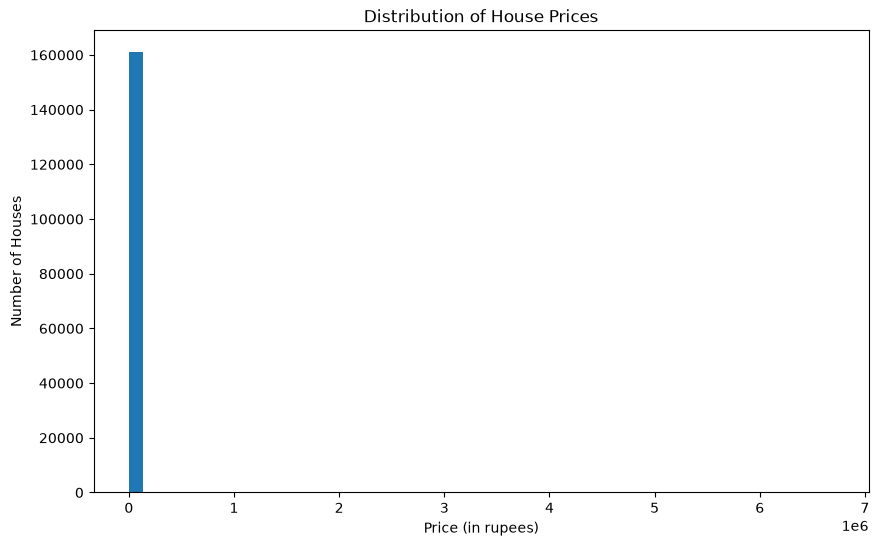

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["Price (in rupees)"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price (in rupees)")
plt.ylabel("Number of Houses")

plt.show()

In [28]:
print(df["Price (in rupees)"].describe())

count    1.609110e+05
mean     7.579545e+03
std      2.563185e+04
min      0.000000e+00
25%      4.316000e+03
50%      6.047000e+03
75%      9.375000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64


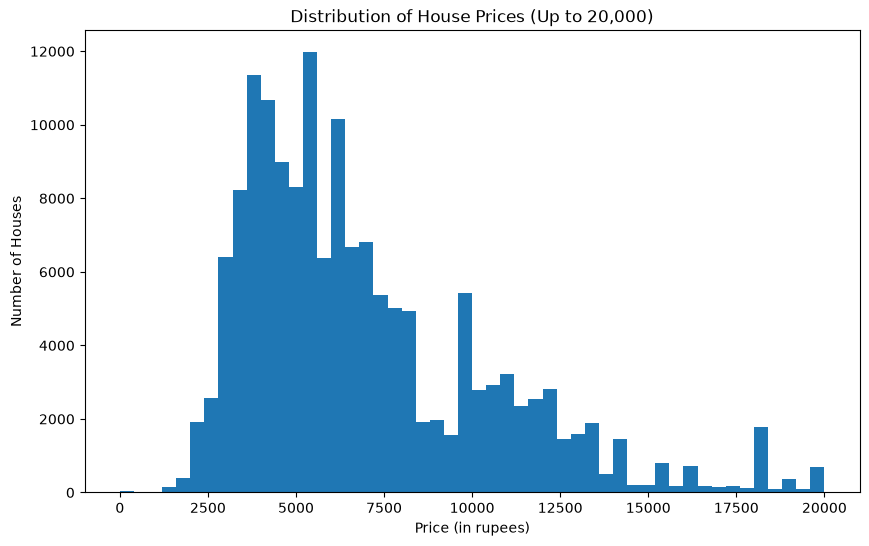

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    df[df["Price (in rupees)"] <= 20000]["Price (in rupees)"],
    bins=50
)

plt.title("Distribution of House Prices (Up to 20,000)")
plt.xlabel("Price (in rupees)")
plt.ylabel("Number of Houses")

plt.show()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_7692\2117578406.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price (in rupees)"], vert=False)


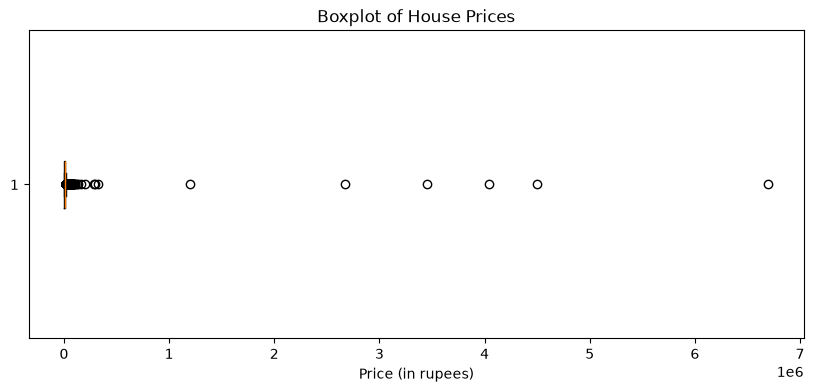

In [30]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["Price (in rupees)"], vert=False)

plt.title("Boxplot of House Prices")
plt.xlabel("Price (in rupees)")

plt.show()

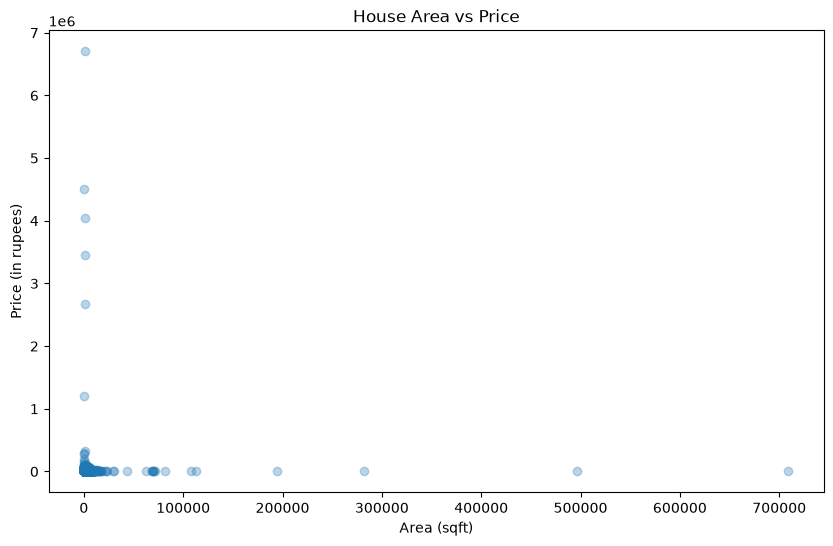

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(df["area"], df["Price (in rupees)"], alpha=0.3)

plt.title("House Area vs Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (in rupees)")

plt.show()

<Figure size 1000x600 with 0 Axes>

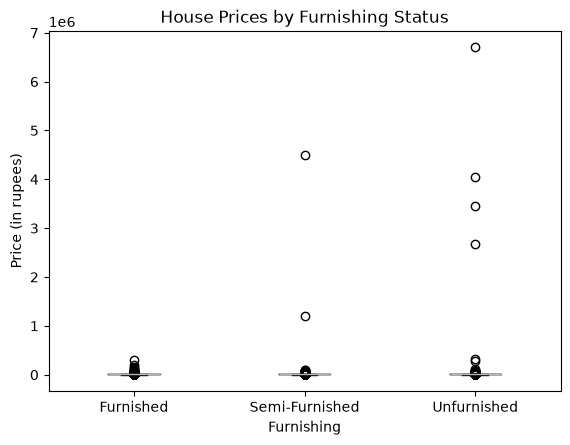

In [32]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="Price (in rupees)",
    by="Furnishing",
    grid=False
)

plt.title("House Prices by Furnishing Status")
plt.suptitle("")
plt.xlabel("Furnishing")
plt.ylabel("Price (in rupees)")

plt.show()

In [33]:
df.isna().sum().sort_values(ascending=False)

Society              91011
Super Area           89044
Car Parking          84726
Carpet Area          71867
overlooking          67234
facing               59191
Ownership            55828
Balcony              43623
balcony_num          43623
floor_num             6780
Floor                 6779
Description           2853
Furnishing            1987
bathroom_num           704
Bathroom               704
Status                 585
Transaction              6
location                 0
Title                    0
Index                    0
Price (in rupees)        0
Amount(in rupees)        0
area                     0
dtype: int64

In [34]:
for col in ["Furnishing", "Status", "Transaction"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Furnishing ---
Furnishing
Semi-Furnished    76962
Unfurnished       65074
Furnished         16888
NaN                1987
Name: count, dtype: int64

--- Status ---
Status
Ready to Move    160326
NaN                 585
Name: count, dtype: int64

--- Transaction ---
Transaction
Resale          121909
New Property     38990
NaN                  6
Other                4
Rent/Lease           2
Name: count, dtype: int64


In [35]:
for col in ["floor_num", "bathroom_num", "balcony_num"]:
    df[col] = df[col].fillna(df[col].median())

print(df[["floor_num", "bathroom_num", "balcony_num"]].isna().sum())

floor_num       0
bathroom_num    0
balcony_num     0
dtype: int64


In [36]:
df["Furnishing"] = df["Furnishing"].fillna("Unknown")

print(df["Furnishing"].value_counts())

Furnishing
Semi-Furnished    76962
Unfurnished       65074
Furnished         16888
Unknown            1987
Name: count, dtype: int64


In [37]:
df["Status"] = df["Status"].fillna("Ready to Move")

print(df["Status"].value_counts())

Status
Ready to Move    160911
Name: count, dtype: int64


In [38]:
df["Transaction"] = df["Transaction"].fillna("Unknown")

print(df["Transaction"].value_counts())

Transaction
Resale          121909
New Property     38990
Unknown              6
Other                4
Rent/Lease           2
Name: count, dtype: int64


In [39]:
features_check = [
    "area",
    "floor_num",
    "bathroom_num",
    "balcony_num",
    "Furnishing",
    "Transaction"
]

print(df[features_check].isna().sum())

area            0
floor_num       0
bathroom_num    0
balcony_num     0
Furnishing      0
Transaction     0
dtype: int64


In [40]:
model_features = [
    "location",
    "area",
    "floor_num",
    "bathroom_num",
    "balcony_num",
    "Furnishing",
    "Transaction"
]

target = "Price (in rupees)"

model_df = df[model_features + [target]].copy()

print(model_df.shape)
print(model_df.head())

(160911, 8)
  location   area  floor_num  bathroom_num  balcony_num      Furnishing  \
0    thane  500.0       10.0           1.0          2.0     Unfurnished   
1    thane  473.0        3.0           2.0          2.0  Semi-Furnished   
2    thane  779.0       10.0           2.0          2.0     Unfurnished   
4    thane  635.0       20.0           2.0          2.0     Unfurnished   
5    thane  680.0        2.0           1.0          1.0     Unfurnished   

  Transaction  Price (in rupees)  
0      Resale             6000.0  
1      Resale            13799.0  
2      Resale            17500.0  
4      Resale            18824.0  
5      Resale             6618.0  


In [41]:
print("Price = 0:", (model_df["Price (in rupees)"] == 0).sum())
print("Price < 0:", (model_df["Price (in rupees)"] < 0).sum())

Price = 0: 7
Price < 0: 0


In [43]:
model_df = model_df[model_df["Price (in rupees)"] > 0].copy()

print(model_df.shape)
print("Minimum price:", model_df["Price (in rupees)"].min())

(160904, 8)
Minimum price: 1.0


In [44]:
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["location", "Furnishing", "Transaction"],
    drop_first=True
)

print(model_df_encoded.shape)
print(model_df_encoded.head())

(160904, 92)
    area  floor_num  bathroom_num  balcony_num  Price (in rupees)  \
0  500.0       10.0           1.0          2.0             6000.0   
1  473.0        3.0           2.0          2.0            13799.0   
2  779.0       10.0           2.0          2.0            17500.0   
4  635.0       20.0           2.0          2.0            18824.0   
5  680.0        2.0           1.0          1.0             6618.0   

   location_ahmadnagar  location_ahmedabad  location_allahabad  \
0                False               False               False   
1                False               False               False   
2                False               False               False   
4                False               False               False   
5                False               False               False   

   location_aurangabad  location_badlapur  ...  location_visakhapatnam  \
0                False              False  ...                   False   
1                False     

In [45]:
X = model_df_encoded.drop(columns=["Price (in rupees)"])
y = model_df_encoded["Price (in rupees)"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (160904, 91)
y shape: (160904,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (128723, 91)
X_test: (32181, 91)
y_train: (128723,)
y_test: (32181,)


In [47]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 2480.705721671263
RMSE: 4404.311458661964
R²  : 0.257751242809368


In [49]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [50]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 834.6061467941794
RMSE: 14496.516520649118
R²  : -7.041197744112241


In [51]:
errors_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_rf
})

errors_df["absolute_error"] = abs(
    errors_df["actual"] - errors_df["predicted"]
)

print(errors_df.sort_values(
    "absolute_error",
    ascending=False
).head(10))

         actual     predicted  absolute_error
2271     3243.0  1.610415e+06    1.607172e+06
9687     2234.0  1.476835e+06    1.474601e+06
8798     3596.0  9.897052e+05    9.861092e+05
25938    2900.0  7.458961e+05    7.429961e+05
27012    3476.0  3.498478e+05    3.463718e+05
11198  282609.0  1.507146e+04    2.675375e+05
21876    2756.0  2.699004e+05    2.671444e+05
25675    3100.0  1.752713e+05    1.721713e+05
27503    2909.0  1.628133e+05    1.599043e+05
10213    2100.0  9.223073e+04    9.013073e+04


In [52]:
print(model_df["Price (in rupees)"].describe())

print("\nPrice percentiles:")
print(model_df["Price (in rupees)"].quantile([0.90, 0.95, 0.99, 0.995, 0.999]))

count    1.609040e+05
mean     7.579875e+03
std      2.563235e+04
min      1.000000e+00
25%      4.317000e+03
50%      6.047000e+03
75%      9.375000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

Price percentiles:
0.900    12714.00
0.950    16513.55
0.990    24000.00
0.995    31447.00
0.999    46889.55
Name: Price (in rupees), dtype: float64


In [53]:
y_log = np.log1p(y)

print("Original target:")
print(y.describe())

print("\nLog-transformed target:")
print(y_log.describe())

Original target:
count    1.609040e+05
mean     7.579875e+03
std      2.563235e+04
min      1.000000e+00
25%      4.317000e+03
50%      6.047000e+03
75%      9.375000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

Log-transformed target:
count    160904.000000
mean          8.762671
std           0.532213
min           0.693147
25%           8.370548
50%           8.707483
75%           9.145909
max          15.717618
Name: Price (in rupees), dtype: float64


In [54]:
rf_log_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_log_model.fit(X_train, np.log1p(y_train))

print("Random Forest with Log Target trained successfully!")

Random Forest with Log Target trained successfully!


In [55]:
y_pred_rf_log = rf_log_model.predict(X_test)

# Convert predictions back to original price scale
y_pred_rf_log_original = np.expm1(y_pred_rf_log)

print("Predictions generated successfully!")

Predictions generated successfully!


In [56]:
mae_rf_log = mean_absolute_error(y_test, y_pred_rf_log_original)
rmse_rf_log = np.sqrt(mean_squared_error(y_test, y_pred_rf_log_original))
r2_rf_log = r2_score(y_test, y_pred_rf_log_original)

print("Random Forest with Log Target Results")
print("--------------------------------------")
print("MAE :", mae_rf_log)
print("RMSE:", rmse_rf_log)
print("R²  :", r2_rf_log)

Random Forest with Log Target Results
--------------------------------------
MAE : 619.5676111083355
RMSE: 2442.553196069369
R²  : 0.7717128352192583


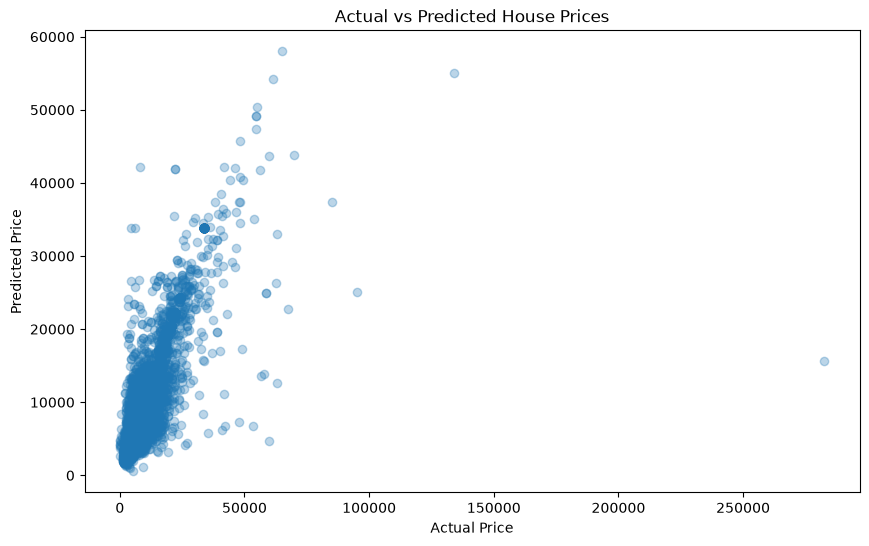

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_rf_log_original,
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

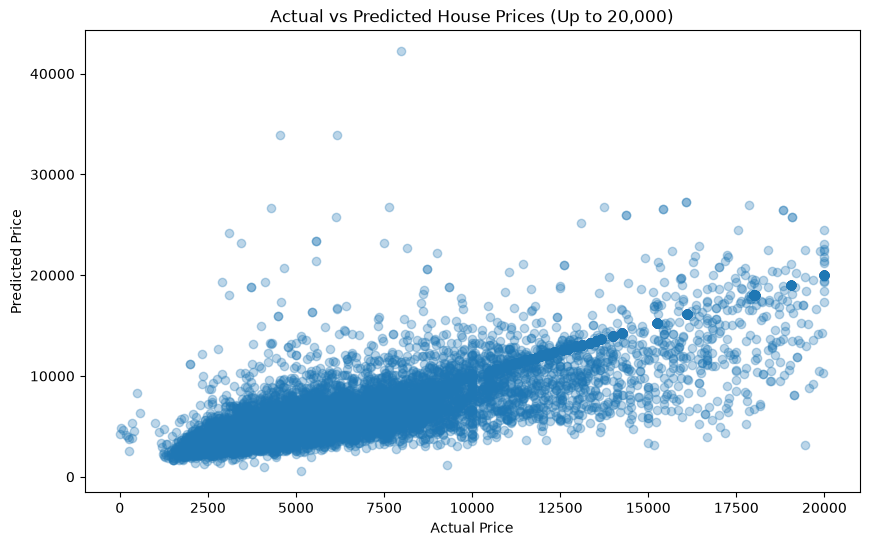

In [58]:
plt.figure(figsize=(10, 6))

mask = y_test <= 20000

plt.scatter(
    y_test[mask],
    y_pred_rf_log_original[mask],
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Up to 20,000)")

plt.show()

In [59]:
import joblib

joblib.dump(rf_log_model, "house_price.pkl")

print("Model saved successfully!")

Model saved successfully!


In [60]:
import json

locations = sorted(model_df["location"].dropna().unique().tolist())

with open("locations.json", "w", encoding="utf-8") as f:
    json.dump(locations, f, ensure_ascii=False, indent=2)

print("Locations saved successfully!")
print("Number of locations:", len(locations))

Locations saved successfully!
Number of locations: 81


In [61]:
import json

feature_columns = X.columns.tolist()

with open("feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_columns, f, ensure_ascii=False, indent=2)

print("Feature columns saved:", len(feature_columns))

Feature columns saved: 91
